In [ ]:
import seaborn as sns
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
from matplotlib.ticker import ScalarFormatter

sns.set()


api = wandb.Api()

project = api.runs("naoki-shitanda/sapg_anymal")
task_name = "Anymal"
metric = "rewards/step"
metric_name = "Episode Rewards"


print(len(project))    
task_runs = {
    "SAPG": [],
    "PPO": [],
    #"PBT": [],
    "CPO2(wo/AdR)": [],
    #"CPO2(w/AdR)": [],
}

# 各手法名がrun.tagに含まれているrunを抽出
for key in task_runs.keys():
    for run in project:
        if any(key in tag for tag in run.tags):
            task_runs[key].append(run)


print(task_runs)
for key in task_runs.keys():
    print(key,":", len(task_runs[key]))
    

49
{'SAPG': [<Run naoki-shitanda/sapg_humanoid/uid_00_0725-SAPG-24576_ent0002_24576envs_mixed_expl_learn_param_lf_1p_27_07_01h48m31s_seed3 (failed)>, <Run naoki-shitanda/sapg_humanoid/uid_00_0725-SAPG-24576_ent0002_24576envs_mixed_expl_learn_param_lf_1p_26_07_16h40m26s_seed4 (running)>, <Run naoki-shitanda/sapg_humanoid/uid_00_0725-SAPG-24576_ent0002_24576envs_mixed_expl_learn_param_lf_1p_26_07_22h43m51s_seed0 (failed)>, <Run naoki-shitanda/sapg_humanoid/uid_00_0725-SAPG-24576_ent0002_24576envs_mixed_expl_learn_param_lf_1p_26_07_22h42m00s_seed2 (failed)>, <Run naoki-shitanda/sapg_humanoid/uid_00_0725-SAPG-24576_ent0002_24576envs_mixed_expl_learn_param_lf_1p_26_07_22h40m11s_seed1 (failed)>], 'PPO': [<Run naoki-shitanda/sapg_humanoid/uid_00_0724-PPO-24576_24576envs_none_none_1p_26_07_16h49m20s_seed1 (failed)>, <Run naoki-shitanda/sapg_humanoid/uid_00_0724-PPO-24576_24576envs_none_none_1p_26_07_16h34m51s_seed2 (failed)>, <Run naoki-shitanda/sapg_humanoid/uid_00_0724-PPO-24576_24576envs_no

In [ ]:
print(task_runs["SAPG"][0].summary)

{'_runtime': 62995, '_step': 25999, '_timestamp': 1753611592.4504292, '_wandb': {'runtime': 63016}, 'auxiliary_stats/off_on_grad_similarity': 0, 'auxiliary_stats/off_on_relative_grad_norms': 0, 'auxiliary_stats/off_policy_contrib': {'_type': 'histogram'}, 'auxiliary_stats/on_policy_contrib': {'_type': 'histogram'}, 'episode_lengths/iter': 928.3894653320312, 'episode_lengths/step': 928.3894653320312, 'episode_lengths/time': 928.3894653320312, 'global_step': 10223222784, 'info/e_clip': 0.20000000298023224, 'info/epochs': 26000, 'info/kl': 0.01185803022235632, 'info/last_lr': 1.1390625331841877e-05, 'info/lr_mul': 1, 'intr_rewards/entropy_block_0': 8.036084175109863, 'intr_rewards/entropy_block_1': 6.870948791503906, 'intr_rewards/entropy_block_2': 6.078671455383301, 'intr_rewards/entropy_block_3': 5.181711673736572, 'intr_rewards/entropy_block_4': 4.083878517150879, 'intr_rewards/entropy_block_5': 5.9777631759643555, 'losses/a_loss': 0.0034602440427988768, 'losses/bounds_loss': 17.674139

In [ ]:
def calc_mean_std(runs, metric="rewards/step"):
    
    seed_dfs = []
    seeds = [run.config.get("seed", "not found") for run in runs]
    seed_set = set(seeds)
    
    # seedごとにデータを取得
    for seed in seed_set:
        print(seed, end=":")
        seed_runs = [run for run in runs if run.config.get("seed") == seed]
        seed_runs = sorted(seed_runs, key=lambda run: run.created_at) # 古い順に並べる
        dfs = []
        
        for i in range(len(seed_runs)):
            df = seed_runs[i].history(keys=[metric, "global_step"])
            df = df.set_index("global_step")
            df = df.dropna() # 欠損値を削除
            
            if i > 0:
                df = df.iloc[40:] # 先頭の行を削除
                # 前のrunの最後のglobal_stepより大きい値のみを保持
                if len(dfs) > 0:
                    last_step = dfs[-1].index.max()
                    df = df[df.index > last_step]
                
            dfs.append(df)
        
        # 連結前にインデックスが単調増加になるようにソート
        seed_df = pd.concat(dfs, axis=0)
        seed_df = seed_df.sort_index()  # global_stepでソート
        
        # 重複するインデックスを削除（最後のものを保持）
        seed_df = seed_df[~seed_df.index.duplicated(keep='last')]
        
        seed_df = seed_df.rename(columns={metric: f"seed{seed}"})    
        if "_step" in seed_df.columns:
            seed_df = seed_df.drop("_step", axis=1) # seed_dfから_stepを削除
    
        seed_dfs.append(seed_df)
        
    # 各seedのデータを連結して1つのデータフレームにする
    merged = pd.concat(seed_dfs, axis=1)
    
    # インデックスをソートして単調増加にする
    merged = merged.sort_index()
    
    # 内挿（左方向のみ、右方向は補完しない）
    merged = merged.interpolate(method="linear", limit_direction="backward")
    
    # 平均と標準偏差を計算
    mean = merged.mean(axis=1)
    std = merged.std(axis=1)
    
    return mean, std

# プロット
colours = {
    "SAPG": "green",
    "PPO": "blue",
    "PBT": "purple",
    "CPO2(wo/AdR)": "red",
    "CPO2(w/AdR)": "red"
}
styles = {
    "SAPG": (10, (5, 3, 1, 3, 1, 3)),
    "PPO": ":",
    "PBT": "-.",
    "CPO2(wo/AdR)": "-",
    "CPO2(w/AdR)": "-"
}




SAPG : 0:

1:2:3:4:
PPO : 0:1:2:3:4:
CPO2(wo/AdR) : 0:1:2:3:4:


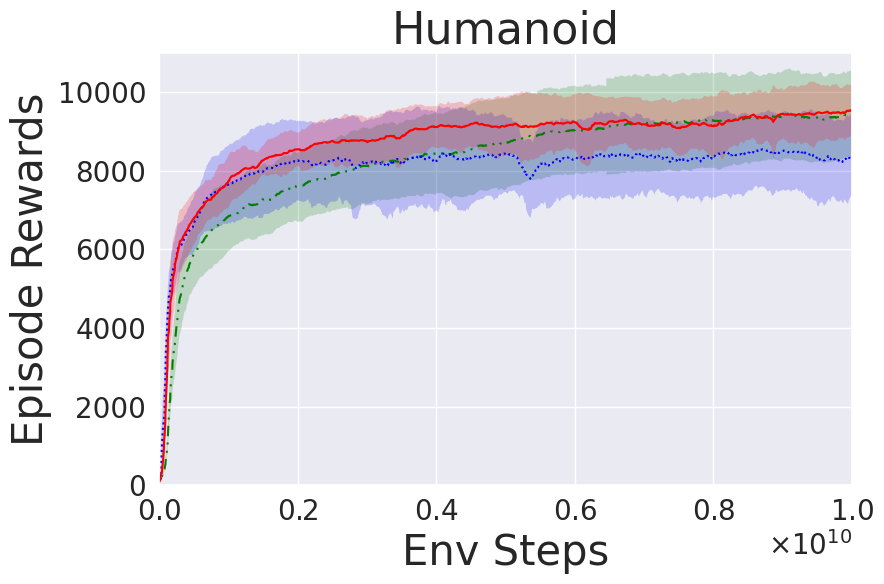

In [ ]:
plt.figure(figsize=(9, 6))

for key in task_runs.keys():
    if len(task_runs[key]) == 0:
        continue
    print(key, ": ", end="")
    runs = task_runs[key]
    mean, std = calc_mean_std(runs, metric=metric)
    plt.plot(mean.index, mean.values, label=key, color=colours[key], linestyle=styles[key])
    plt.fill_between(mean.index, mean - std, mean + std, alpha=0.2, color=colours[key], edgecolor="none")
    print("")

plt.xlabel("Env Steps", fontsize=30)
plt.ylabel(metric_name, fontsize=30)
plt.title(task_name, fontsize=32)
plt.grid(True)
plt.xlim(0, 2e10)
if "Humanoid" in task_name:
    plt.xlim(0, 1.0e10) # Humanoid
elif "Anymal" in task_name:
    plt.xlim(0, 5e9)

plt.ylim(0, 16000) # Allegro Hand
if "Shadow " in task_name:
    plt.ylim(0, 14500) # Shadow
elif "Allegro Hand" in task_name:
    plt.ylim(0, 16000) # Allegro Hand
elif "Humanoid" in task_name:
    plt.ylim(0, 11000)
elif "Anymal" in task_name:
    plt.ylim(0, 80)



plt.tight_layout(rect=[0, 0.07, 1, 1])




ax = plt.gca()
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))  # 必ず指数表記を使う
ax.xaxis.set_major_formatter(formatter)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax.xaxis.get_offset_text().set_fontsize(20)

plt.tick_params(axis='both', labelsize=20)  # 両軸の目盛を大きくする
plt.tight_layout()



plt.savefig("fig.svg")